In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

## Missing Values

In [2]:
df.isnull().sum().sum() 

np.int64(0)

## Scaling

In [4]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Initialize and apply scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())
print(X_scaled.describe())  # mean ~0, std ~1 for each column

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0     1.097064     -2.073335        1.269934   0.984375         1.568466   
1     1.829821     -0.353632        1.685955   1.908708        -0.826962   
2     1.579888      0.456187        1.566503   1.558884         0.942210   
3    -0.768909      0.253732       -0.592687  -0.764464         3.283553   
4     1.750297     -1.151816        1.776573   1.826229         0.280372   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0          3.283515        2.652874             2.532475       2.217515   
1         -0.487072       -0.023846             0.548144       0.001392   
2          1.052926        1.363478             2.037231       0.939685   
3          3.402909        1.915897             1.451707       2.867383   
4          0.539340        1.371011             1.428493      -0.009560   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

## Split data

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Linear Kernel

In [9]:
# Build SVM classifier with linear kernel
svm_clf = SVC(kernel='linear', random_state=42)
svm_clf.fit(X_train_scaled, y_train)

# Predictions
y_pred = svm_clf.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=data.target_names))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Confusion Matrix:
 [[41  1]
 [ 2 70]]


## RBF Kernel

In [10]:
# Build SVM classifier with RBF kernel
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

# Predictions
y_pred_rbf = svm_rbf.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rbf, target_names=data.target_names))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))

Accuracy: 0.9824561403508771

Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix:
 [[41  1]
 [ 1 71]]


## Polynomial Kernel

In [11]:
# Build SVM classifier with polynomial kernel
svm_poly = SVC(kernel='poly', degree=3, random_state=42)
svm_poly.fit(X_train_scaled, y_train)

# Predictions
y_pred_poly = svm_poly.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_poly))
print("\nClassification Report:\n", classification_report(y_test, y_pred_poly, target_names=data.target_names))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_poly))

Accuracy: 0.9122807017543859

Classification Report:
               precision    recall  f1-score   support

   malignant       1.00      0.76      0.86        42
      benign       0.88      1.00      0.94        72

    accuracy                           0.91       114
   macro avg       0.94      0.88      0.90       114
weighted avg       0.92      0.91      0.91       114


Confusion Matrix:
 [[32 10]
 [ 0 72]]


## Sigmoid Kernel

In [12]:
# Build SVM classifier with sigmoid kernel
svm_sigmoid = SVC(kernel='sigmoid', random_state=42)
svm_sigmoid.fit(X_train_scaled, y_train)

# Predictions
y_pred_sigmoid = svm_sigmoid.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_sigmoid))
print("\nClassification Report:\n", classification_report(y_test, y_pred_sigmoid, target_names=data.target_names))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_sigmoid))

Accuracy: 0.9298245614035088

Classification Report:
               precision    recall  f1-score   support

   malignant       0.89      0.93      0.91        42
      benign       0.96      0.93      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114


Confusion Matrix:
 [[39  3]
 [ 5 67]]


## Kernels Comparision

linear: 0.974
rbf: 0.982
poly: 0.912
sigmoid: 0.930


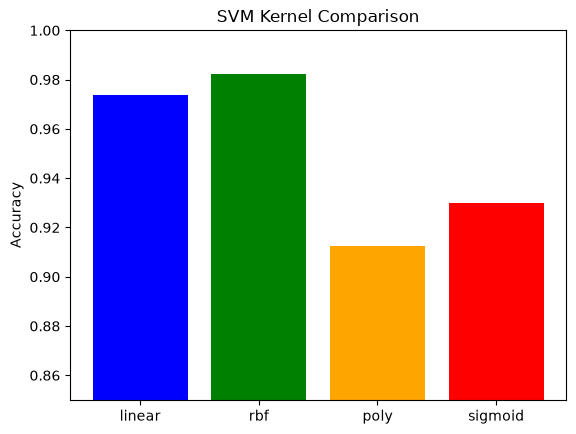

In [17]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load and prepare data
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train each kernel and collect accuracy
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
accuracies = []

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracies.append(acc)
    print(f'{k}: {acc:.3f}')

# Visualize
plt.bar(kernels, accuracies, color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Accuracy')
plt.title('SVM Kernel Comparison')
plt.ylim(0.85, 1.0)
plt.show()

In [20]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

## Hyperparameter Tunning C

In [ ]:
# Grid search over C
param_grid = {'C': [0.1, 1, 10, 100]}
grid = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy'
)
grid.fit(X_train_scaled, y_train)

# Results
print('Best C:', grid.best_params_['C'])
print('Best CV Accuracy:', grid.best_score_)

# Evaluate best model on test set
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)
print('\nTest Accuracy:', accuracy_score(y_test, y_pred))
print('\n', classification_report(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Best C: 10
Best CV Accuracy: 0.9692307692307693

Test Accuracy: 0.9736842105263158

               precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
 [[41  1]
 [ 2 70]]


## Hyperparameter gamma 

In [ ]:
# Grid search over gamma (C fixed at default = 1)
param_grid = {'gamma': [0.01, 0.1, 1, 10]}
grid = GridSearchCV(
    SVC(kernel='rbf', C=1, random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy'
)
grid.fit(X_train_scaled, y_train)

# Results
print('Best gamma:', grid.best_params_['gamma'])
print('Best CV Accuracy:', grid.best_score_)

# Evaluate best model on test set
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)
print('\nTest Accuracy:', accuracy_score(y_test, y_pred))
print('\n', classification_report(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Best gamma: 0.01
Best CV Accuracy: 0.9714285714285715

Test Accuracy: 0.9824561403508771

               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
 [[41  1]
 [ 1 71]]


## GridsearchCv

In [29]:
# Joint grid search over C and gamma
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10]
}
grid = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

# Best parameters
print('Best params:', grid.best_params_)
print('Best CV Accuracy:', grid.best_score_)

# Evaluate best model on test set
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)
print('\nTest Accuracy:', accuracy_score(y_test, y_pred))
print('\n', classification_report(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

Best params: {'C': 10, 'gamma': 0.01}
Best CV Accuracy: 0.9758241758241759

Test Accuracy: 0.9824561403508771

               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
 [[41  1]
 [ 1 71]]


## Evaluate metrics

Accuracy: 0.982
Precision: 0.986
Recall: 0.986
F1-score: 0.986
ROC-AUC: 0.998


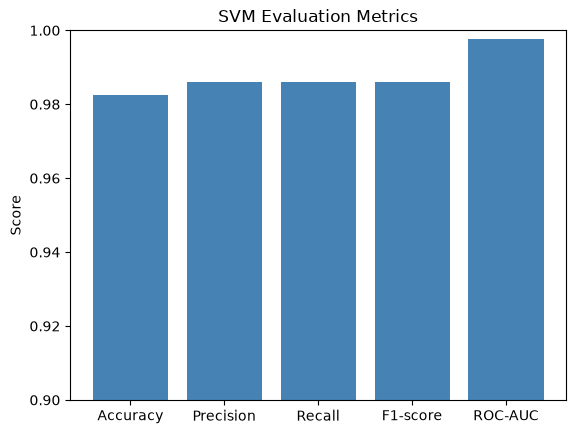

Confusion Matrix:
 [[41  1]
 [ 1 71]]


In [30]:
# Metrics
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}

for name, val in metrics.items():
    print(f'{name}: {val:.3f}')

# Visualize
plt.bar(metrics.keys(), metrics.values(), color='steelblue')
plt.ylim(0.9, 1.0)
plt.title('SVM Evaluation Metrics')
plt.ylabel('Score')
plt.show()

print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))